# IT Support Dashboard – Supporting Notebook 2

This notebook assesses whether the English-language subset is suitable for downstream text modelling. It evaluates marginal and joint metadata distributions, tag prevalence, text quality and length, statistical uncertainty, and the extent to which metadata predicts language.

The result is a scoped decision gate. It does not establish that English and German tickets have equivalent wording, themes, or semantic content.

## Assessment framework

The notebook separates three questions:

1. **How does filtering change the exported population?** English-only proportions are compared with the full cleaned population.
2. **How different are the independent language groups?** English and German records are compared using practical distances, chi-square tests, Cramér's V, residual diagnostics, and bootstrap intervals.
3. **Is the English text ready for modelling?** Tags, missing or malformed text, duplication, text length, joint metadata patterns, and version sensitivity are reviewed.

`PASS`, `PASS with caution`, and `FAIL` are based on configured practical tolerances. Statistical significance is a caution diagnostic rather than the primary criterion.

### Importing and schema validation

The clean Parquet output from Notebook 1 is loaded, and the fields required by the representativeness and text-readiness checks are validated before analysis begins.

In [1]:
import sys
from pathlib import Path

# Import numerical, visualisation, statistical, and modelling libraries.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import display

# Locate the project root containing config.py
# Search the current directory and its parents so the notebook is location-independent.
project_root = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents]
     if (candidate / "config.py").exists()),
    None,
)

# Fail clearly if the central project configuration cannot be found.
if project_root is None:
    raise FileNotFoundError("Could not locate the project root containing config.py.")

# Make config.py importable without permanently changing the Python environment.
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from config import Config  # noqa: E402

# Create or verify the configured output directories before saving artefacts.
Config.ensure_directories()

# Load the cleaned output created by the quality-check notebook.
df = pd.read_parquet(Config.CLEAN_PARQUET_PATH, engine="auto")

# Pair output-number prefixes with the metadata dimensions used in comparisons.
comparison_dimensions = [
    ("02", "Priority"),
    ("03", "Type"),
    ("04", "Queue"),
    ("05", "Version"),
]
# Define the text fields that must be suitable for downstream NLP.
text_columns = ["Subject", "Body", "Answer"]
# Discover and numerically order Tag_1, Tag_2, and subsequent tag columns.
tag_columns = sorted(
    [column for column in df.columns if column.startswith("Tag_")],
    key=lambda column: int(column.removeprefix("Tag_")),
)

# Build the complete minimum schema required by this notebook.
required_columns = {
    "Index",
    "Language",
    *text_columns,
    *(column for _, column in comparison_dimensions),
    *tag_columns,
}
# Compare the required schema with the columns actually loaded.
missing_columns = required_columns.difference(df.columns)

# Stop early rather than allowing a later calculation to fail ambiguously.
if missing_columns:
    raise KeyError(f"Required columns are missing: {sorted(missing_columns)}")

# An empty clean dataset cannot support distribution or text checks.
if df.empty:
    raise ValueError("The cleaned dataset is empty.")

# Confirm that source identifiers remain complete and unique after cleaning.
if df["Index"].isna().any() or df["Index"].duplicated().any():
    raise ValueError("Index must contain unique, non-null source record identifiers.")

print(f"Loaded clean dataset: {len(df):,} rows × {df.shape[1]:,} columns")
print(f"Detected tag columns: {len(tag_columns)}")
display(df.head())

[Config] Verified project directory structure under C:\Users\cosmi\Documents\Projects\IT-Support-Ticket-Analysis
Loaded clean dataset: 24,743 rows × 17 columns
Detected tag columns: 8


,Index,Subject,Body,Answer,Type,Queue,Priority,Language,Version,Tag_1,Tag_2,Tag_3,Tag_4,Tag_5,Tag_6,Tag_7,Tag_8
0,0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team, ich möchte einen g...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,High,DE,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,1,Account Disruption,"Dear Customer Support Team, I am writing to re...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,High,EN,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team, I hope this messag...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,Medium,EN,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,3,Inquiry Regarding Invoice Details,"Dear Customer Support Team, I hope this messag...",We appreciate you reaching out with your billi...,Request,Billing and Payments,Low,EN,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,4,Question About Marketing Agency Software Compa...,"Dear Support Team, I hope this message reaches...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,Medium,EN,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


### Language composition

The language field is checked for missing or unexpected labels before independent English and German subsets are created. Export is deferred until the final gate has been evaluated.

In [2]:
# Restrict this workflow to the two language groups it is designed to compare.
expected_languages = {"EN", "DE"}
# Read the distinct non-null labels present in the cleaned data.
observed_languages = set(df["Language"].dropna().astype("string").unique())

# Missing language labels would cause records to disappear from both subsets.
if df["Language"].isna().any():
    raise ValueError("Language contains null values.")

# Reject unexpected labels rather than silently excluding another language.
if observed_languages != expected_languages:
    raise ValueError(
        f"Expected language values {sorted(expected_languages)}, found "
        f"{sorted(observed_languages)}."
    )

# Create independent copies so later transformations cannot mutate the source data.
df_en = df.loc[df["Language"] == "EN"].copy()
df_de = df.loc[df["Language"] == "DE"].copy()
# Store group sizes for prevalence denominators used later in the notebook.
language_sizes = {"EN": len(df_en), "DE": len(df_de)}

# Produce a compact audit table of language counts and proportions.
language_summary = pd.DataFrame(
    {
        "Language": ["English", "German"],
        "Count": [len(df_en), len(df_de)],
        "Proportion": [len(df_en) / len(df), len(df_de) / len(df)],
    }
)

display(language_summary.style.format({"Count": "{:,}", "Proportion": "{:.2%}"}))

,Language,Count,Proportion
0,English,"13,729",55.49%
1,German,"11,014",44.51%


### Statistical utilities

The following functions provide consistent distribution tables, effect sizes, adjusted residuals, and false-discovery-rate correction throughout the notebook.

In [3]:
def cramers_v(chi_square, sample_size, row_count, column_count):
    """Calculate Cramér's V for a contingency table."""
    # Scale chi-square by sample size and the smaller table dimension.
    denominator = sample_size * min(row_count - 1, column_count - 1)
    # Return a missing effect size when the table has insufficient dimensions.
    if denominator <= 0:
        return np.nan
    return np.sqrt(chi_square / denominator)


def benjamini_hochberg(p_values):
    """Return Benjamini–Hochberg-adjusted p-values."""
    # Convert input to a numeric array and retain the original test ordering.
    p_values = np.asarray(p_values, dtype=float)
    count = len(p_values)
    # Sort p-values because the correction is applied by ascending rank.
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted_ranked = np.empty(count, dtype=float)

    previous = 1.0
    # Work backwards so adjusted p-values remain monotonic across ranks.
    for index in range(count - 1, -1, -1):
        rank = index + 1
        previous = min(previous, ranked[index] * count / rank)
        adjusted_ranked[index] = previous

    adjusted = np.empty(count, dtype=float)
    # Restore adjusted values to the dimensions' original order.
    adjusted[order] = np.clip(adjusted_ranked, 0, 1)
    return adjusted


def full_subset_comparison(full_df, subset_df, column):
    """Compare a subset with the population that contains it."""
    # Count every category in the full population and English subset.
    full_counts = full_df[column].value_counts(dropna=False)
    subset_counts = subset_df[column].value_counts(dropna=False)
    # Align categories that may appear in only one of the two datasets.
    result = (
        pd.concat(
            [subset_counts.rename("English Count"), full_counts.rename("Full Count")],
            axis=1,
        )
        .fillna(0)
        .astype({"English Count": "int64", "Full Count": "int64"})
        .reset_index(names=column)
    )
    # Convert counts to proportions using each dataset's own denominator.
    result["English Pct"] = result["English Count"] / len(subset_df)
    result["Full Pct"] = result["Full Count"] / len(full_df)
    # Positive values indicate over-representation in the English subset.
    result["Signed Pct Diff"] = result["English Pct"] - result["Full Pct"]
    result["Absolute Pct Diff"] = result["Signed Pct Diff"].abs()
    return result.sort_values("Full Count", ascending=False).reset_index(drop=True)


def language_contingency(data, column):
    """Return a populated category-by-language contingency table."""
    # Cross-tabulate category counts for the independent language groups.
    table = pd.crosstab(data[column], data["Language"], dropna=False)
    table = table.reindex(columns=["EN", "DE"], fill_value=0)
    return table.loc[table.sum(axis=1) > 0]


def language_distribution(data, column):
    """Compare independent English and German category proportions."""
    table = language_contingency(data, column)
    # Normalise within language so columns each sum to one.
    proportions = table.div(table.sum(axis=0), axis=1)
    result = proportions.rename(
        columns={"EN": "English Pct", "DE": "German Pct"}
    ).reset_index()
    result["Signed Pct Diff"] = result["English Pct"] - result["German Pct"]
    result["Absolute Pct Diff"] = result["Signed Pct Diff"].abs()
    return result, table


def contingency_diagnostics(table):
    """Return chi-square statistics and adjusted standardised residuals."""
    # Test whether category membership and language are independent.
    chi_square, p_value, degrees_of_freedom, expected = stats.chi2_contingency(
        table, correction=False
    )
    observed = table.to_numpy(dtype=float)
    sample_size = observed.sum()
    # Calculate marginal proportions needed for adjusted residuals.
    row_proportions = observed.sum(axis=1, keepdims=True) / sample_size
    column_proportions = observed.sum(axis=0, keepdims=True) / sample_size
    # Adjust residual scaling for both row and column marginal frequencies.
    denominator = np.sqrt(
        expected * (1 - row_proportions) * (1 - column_proportions)
    )
    # Divide observed-minus-expected counts safely, avoiding zero denominators.
    adjusted_residuals = np.divide(
        observed - expected,
        denominator,
        out=np.zeros_like(observed),
        where=denominator > 0,
    )
    # Convert the omnibus chi-square statistic into a practical effect size.
    effect_size = cramers_v(
        chi_square, sample_size, table.shape[0], table.shape[1]
    )
    return {
        "Chi2": chi_square,
        "P Value": p_value,
        "DoF": degrees_of_freedom,
        "n": int(sample_size),
        "Cramers V": effect_size,
        "Min Expected Count": expected.min(),
        "Expected Cells Below 5": int((expected < 5).sum()),
        "Residuals": pd.DataFrame(
            adjusted_residuals, index=table.index, columns=table.columns
        ),
    }


def cliffs_delta(english_values, german_values):
    """Calculate Cliff's delta using the Mann–Whitney U statistic."""
    # Remove missing observations before comparing the two distributions.
    english_values = pd.Series(english_values).dropna()
    german_values = pd.Series(german_values).dropna()
    # Reuse the Mann–Whitney U statistic to calculate Cliff's delta efficiently.
    u_statistic = stats.mannwhitneyu(
        english_values, german_values, alternative="two-sided"
    ).statistic
    return 2 * u_statistic / (len(english_values) * len(german_values)) - 1

### English subset versus the full population

This section measures how restricting the cleaned population to English changes the composition of the dataset supplied to downstream analysis. English-versus-full comparisons are appropriate for describing filtering impact. Because the English subset forms part of the full population, the resulting differences are expected to be smaller than English-versus-German differences and are not used for inferential testing or the formal decision gate.

In [4]:
# Retain detailed tables for plotting and a separate list for summary rows.
full_subset_distributions = {}
full_subset_summaries = []

# Process each monitored dimension using the same reproducible workflow.
for position, column in comparison_dimensions:
    # Measure how English filtering changes this dimension's proportions.
    distribution = full_subset_comparison(df, df_en, column)
    full_subset_distributions[column] = distribution
    # Sum absolute category shifts; total variation is half this value.
    l1_distance = distribution["Absolute Pct Diff"].sum()
    # Identify the single category most affected by English filtering.
    maximum_row = distribution.loc[distribution["Absolute Pct Diff"].idxmax()]

    # Store one summary record for the cross-dimension comparison.
    full_subset_summaries.append(
        {
            "Dimension": column,
            "Max Diff Category": maximum_row[column],
            "Signed Pct Diff at Max": maximum_row["Signed Pct Diff"],
            "Max Abs Pct Diff": maximum_row["Absolute Pct Diff"],
            "L1 Total Abs Pct Diff": l1_distance,
            "Total Variation Distance": l1_distance / 2,
        }
    )

    # Save the complete category-level audit table for this dimension.
    distribution.to_csv(
        Config.REP_SHEETS_DIR / f"{position}_Distribution_Comparison_{column}.csv",
        index=False,
        encoding="latin-1",
    )

    print(f"\nEnglish subset versus full population: {column}")
    display(
        distribution.sort_values("Absolute Pct Diff", ascending=False).style.format(
            {
                "English Count": "{:,}", "Full Count": "{:,}",
                "English Pct": "{:.2%}", "Full Pct": "{:.2%}",
                "Signed Pct Diff": "{:+.2%}", "Absolute Pct Diff": "{:.2%}",
            }
        )
    )

# Combine dimension summaries and rank them by total filtering impact.
absolute_shifts_df = pd.DataFrame(full_subset_summaries).sort_values(
    "L1 Total Abs Pct Diff", ascending=False
).reset_index(drop=True)
absolute_shifts_df.to_csv(
    Config.ABSOLUTE_SHIFT_PATH, index=False, encoding="latin-1"
)
display(
    absolute_shifts_df.style.format(
        {
            "Signed Pct Diff at Max": "{:+.2%}",
            "Max Abs Pct Diff": "{:.2%}",
            "L1 Total Abs Pct Diff": "{:.2%}",
            "Total Variation Distance": "{:.2%}",
        }
    )
)


English subset versus full population: Priority


,Priority,English Count,Full Count,English Pct,Full Pct,Signed Pct Diff,Absolute Pct Diff
0,Medium,"5,593","9,975",40.74%,40.31%,+0.42%,0.42%
1,High,"5,304","9,653",38.63%,39.01%,-0.38%,0.38%
2,Low,"2,832","5,115",20.63%,20.67%,-0.04%,0.04%



English subset versus full population: Type


,Type,English Count,Full Count,English Pct,Full Pct,Signed Pct Diff,Absolute Pct Diff
2,Problem,"2,872","5,230",20.92%,21.14%,-0.22%,0.22%
3,Change,"1,397","2,484",10.18%,10.04%,+0.14%,0.14%
0,Incident,"5,531","9,950",40.29%,40.21%,+0.07%,0.07%
1,Request,"3,929","7,079",28.62%,28.61%,+0.01%,0.01%



English subset versus full population: Queue


,Queue,English Count,Full Count,English Pct,Full Pct,Signed Pct Diff,Absolute Pct Diff
1,Product Support,"2,606","4,560",18.98%,18.43%,+0.55%,0.55%
0,Technical Support,"3,971","7,260",28.92%,29.34%,-0.42%,0.42%
2,Customer Service,"2,045","3,732",14.90%,15.08%,-0.19%,0.19%
3,IT Support,"1,609","2,943",11.72%,11.89%,-0.17%,0.17%
8,Human Resources,285,473,2.08%,1.91%,+0.16%,0.16%
7,Sales and Pre-Sales,410,763,2.99%,3.08%,-0.10%,0.10%
6,Service Outages and Maintenance,581,"1,024",4.23%,4.14%,+0.09%,0.09%
5,Returns and Exchanges,686,"1,226",5.00%,4.95%,+0.04%,0.04%
4,Billing and Payments,"1,349","2,425",9.83%,9.80%,+0.03%,0.03%
9,General Inquiry,187,337,1.36%,1.36%,+0.00%,0.00%



English subset versus full population: Version


,Version,English Count,Full Count,English Pct,Full Pct,Signed Pct Diff,Absolute Pct Diff
0,400,"8,861","16,263",64.54%,65.73%,-1.19%,1.19%
1,52,"4,317","7,611",31.44%,30.76%,+0.68%,0.68%
2,51,551,869,4.01%,3.51%,+0.50%,0.50%


,Dimension,Max Diff Category,Signed Pct Diff at Max,Max Abs Pct Diff,L1 Total Abs Pct Diff,Total Variation Distance
0,Version,400.000000,-1.19%,1.19%,2.37%,1.19%
1,Queue,Product Support,+0.55%,0.55%,1.75%,0.88%
2,Priority,Medium,+0.42%,0.42%,0.85%,0.42%
3,Type,Problem,-0.22%,0.22%,0.44%,0.22%


### Visual comparison

The same English-versus-full proportions are shown as horizontal bars to make the direction and practical size of filtering shifts easier to inspect.

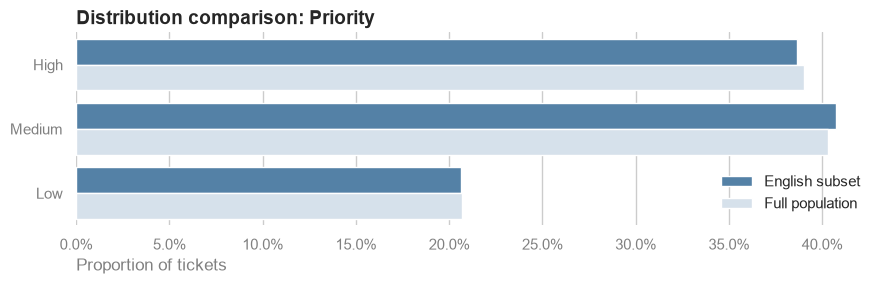

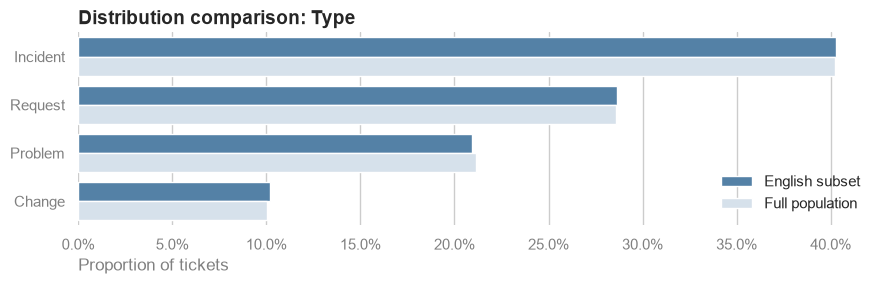

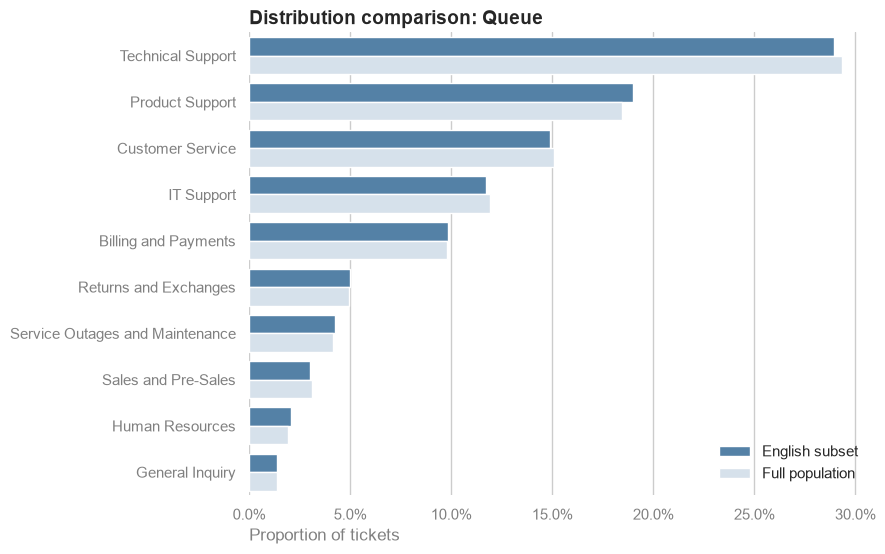

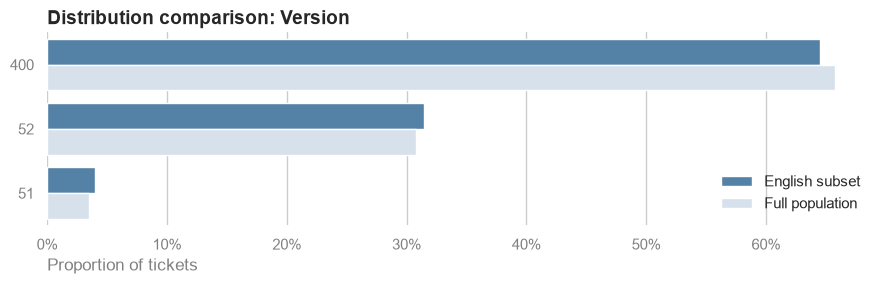

In [5]:
# Apply one consistent visual style to all comparison charts.
sns.set_theme(style="whitegrid")
# Collect the exact plotting data for an auditable CSV export.
visual_parameter_records = []

# Create one comparison chart per monitored metadata dimension.
for position, column in comparison_dimensions:
    # Reshape the wide proportion columns into Seaborn's long format.
    plot_data = full_subset_distributions[column].melt(
        id_vars=[column],
        value_vars=["Full Pct", "English Pct"],
        var_name="Dataset",
        value_name="Proportion",
    )
    plot_data["Dataset"] = plot_data["Dataset"].replace(
        {"Full Pct": "Full population", "English Pct": "English subset"}
    )

    # Preserve the values used in the figure before display-only conversions.
    visual_parameter_records.append(
        plot_data.assign(Dimension=column)
        .rename(columns={column: "Category"})[
            ["Dimension", "Dataset", "Category", "Proportion"]
        ]
    )

    # Treat numeric-looking versions as labels rather than continuous values.
    if column == "Version":
        plot_data[column] = plot_data[column].astype("string")

    # Use a meaningful urgency order; rank other categories by prevalence.
    if column == "Priority":
        observed = set(plot_data[column].astype("string"))
        order = [value for value in ["High", "Medium", "Low"] if value in observed]
    else:
        order = (
            plot_data.groupby(column, observed=True)["Proportion"]
            .mean().sort_values(ascending=False).index.tolist()
        )

    # Scale chart height to the number of displayed categories.
    fig, ax = plt.subplots(figsize=(9, max(3.0, 1.2 + 0.45 * len(order))))
    # Plot paired English and full-population proportions without error bars.
    sns.barplot(
        data=plot_data, x="Proportion", y=column, hue="Dataset",
        hue_order=["English subset", "Full population"], order=order,
        palette=["steelblue", "#D3E1EE"], errorbar=None, ax=ax,
    )
    ax.set_title(f"Distribution comparison: {column}", loc="left", fontweight="bold", fontsize=14)
    ax.set_xlabel("Proportion of tickets", loc="left", color="grey")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.xaxis.set_tick_params(labelcolor="grey")
    ax.yaxis.set_tick_params(labelcolor="grey")
    ax.legend(title="", frameon=False, loc="lower right")
    sns.despine(ax=ax, left=True, bottom=True)
    fig.tight_layout()
    # Save a publication-quality image, then release the figure from memory.
    fig.savefig(
        Config.REP_IMG_DIR / f"{position}_Distribution_Comparison_{column}.png",
        dpi=300, bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

# Combine and export the data underlying all four charts.
visual_params_df = pd.concat(visual_parameter_records, ignore_index=True)
visual_params_df.to_csv(Config.VISUAL_PARAMS_PATH, index=False, encoding="utf-8")

### Independent language-group comparisons

English and German records are independent groups, so their proportion distances and contingency tables form the practical and inferential decision metrics. Adjusted standardised residuals identify the categories driving each association; absolute residuals of two or more are highlighted for interpretation.

In [6]:
# Maintain separate collections for distances, tests, and residual diagnostics.
language_shift_records = []
test_records = []
residual_records = []

# Compare English and German as independent groups for every dimension.
for _, column in comparison_dimensions:
    # Build both the readable proportion table and its count contingency table.
    distribution, table = language_distribution(df, column)
    # Calculate inferential statistics, effect size, assumptions, and residuals.
    diagnostics = contingency_diagnostics(table)
    l1_distance = distribution["Absolute Pct Diff"].sum()
    maximum_row = distribution.loc[distribution["Absolute Pct Diff"].idxmax()]

    # Store practical distribution distances used by the final gate.
    language_shift_records.append(
        {
            "Dimension": column,
            "Max Diff Category": maximum_row[column],
            "Signed Pct Diff at Max": maximum_row["Signed Pct Diff"],
            "Max Abs Pct Diff": maximum_row["Absolute Pct Diff"],
            "L1 Total Abs Pct Diff": l1_distance,
            "Total Variation Distance": l1_distance / 2,
        }
    )
    # Store scalar test results while keeping the residual matrix separate.
    test_records.append(
        {key: value for key, value in diagnostics.items() if key != "Residuals"}
        | {"Dimension": column}
    )

    # Convert the residual matrix into one row per category-language cell.
    residuals = diagnostics["Residuals"].rename_axis("Category").reset_index()
    residuals = residuals.melt(
        id_vars="Category", var_name="Language", value_name="Adjusted Residual"
    )
    residuals.insert(0, "Dimension", column)
    # Flag cells contributing more strongly than roughly two standard deviations.
    residuals["Flag Abs Residual >= 2"] = residuals["Adjusted Residual"].abs() >= 2
    residual_records.append(residuals)

    print(f"\nEnglish versus German: {column}")
    display(
        distribution.sort_values("Absolute Pct Diff", ascending=False).style.format(
            {
                "English Pct": "{:.2%}", "German Pct": "{:.2%}",
                "Signed Pct Diff": "{:+.2%}", "Absolute Pct Diff": "{:.2%}",
            }
        )
    )

# Assemble the collected records and control FDR across the four tests.
language_shifts_df = pd.DataFrame(language_shift_records)
stats_df = pd.DataFrame(test_records)
stats_df["P Value Adj Bh"] = benjamini_hochberg(stats_df["P Value"])
residuals_df = pd.concat(residual_records, ignore_index=True)

language_shifts_df.to_csv(
    Config.LANGUAGE_SHIFT_PATH, index=False, encoding="latin-1"
)
residuals_df.to_csv(
    Config.RESIDUAL_DIAGNOSTICS_PATH, index=False, encoding="latin-1"
)

display(
    stats_df.style.format(
        {
            "Chi2": "{:.3f}", "P Value": "{:.2e}",
            "P Value Adj Bh": "{:.2e}", "n": "{:,}",
            "Cramers V": "{:.3f}", "Min Expected Count": "{:.2f}",
        }
    )
)
print("\nCategories with |adjusted residual| ≥ 2:")
display(residuals_df.loc[residuals_df["Flag Abs Residual >= 2"]])


English versus German: Priority


Language,Priority,English Pct,German Pct,Signed Pct Diff,Absolute Pct Diff
2,Medium,40.74%,39.79%,+0.95%,0.95%
0,High,38.63%,39.49%,-0.85%,0.85%
1,Low,20.63%,20.73%,-0.10%,0.10%



English versus German: Type


Language,Type,English Pct,German Pct,Signed Pct Diff,Absolute Pct Diff
2,Problem,20.92%,21.41%,-0.49%,0.49%
0,Change,10.18%,9.87%,+0.31%,0.31%
1,Incident,40.29%,40.12%,+0.17%,0.17%
3,Request,28.62%,28.60%,+0.02%,0.02%



English versus German: Queue


...


English versus German: Version


Language,Version,English Pct,German Pct,Signed Pct Diff,Absolute Pct Diff
2,400,64.54%,67.21%,-2.66%,2.66%
1,52,31.44%,29.91%,+1.54%,1.54%
0,51,4.01%,2.89%,+1.13%,1.13%


,Chi2,P Value,DoF,n,Cramers V,Min Expected Count,Expected Cells Below 5,Dimension,P Value Adj Bh
0,2.545,2.80e-01,2,"24,743",0.010,2276.87,0,Priority,3.74e-01
1,1.307,7.27e-01,3,"24,743",0.007,1105.72,0,Type,7.27e-01
2,14.524,1.05e-01,9,"24,743",0.024,150.01,0,Queue,2.10e-01
3,33.356,5.71e-08,2,"24,743",0.037,386.82,0,Version,2.28e-07



Categories with |adjusted residual| ≥ 2:


,Dimension,Category,Language,Adjusted Residual,Flag Abs Residual >= 2
17,Queue,Human Resources,EN,2.106467,True
19,Queue,Product Support,EN,2.501474,True
27,Queue,Human Resources,DE,-2.106467,True
29,Queue,Product Support,DE,-2.501474,True
34,Version,51,EN,4.782432,True
35,Version,52,EN,2.603553,True
36,Version,400,EN,-4.386499,True
37,Version,51,DE,-4.782432,True
38,Version,52,DE,-2.603553,True
39,Version,400,DE,4.386499,True


### Bootstrap uncertainty

Point estimates can conceal sampling variability. Stratified multinomial bootstrap samples preserve each language-group size and provide 95% percentile intervals for L1 distance, total variation distance, and Cramér's V.

In [7]:
# Use a seeded generator so bootstrap intervals are reproducible.
rng = np.random.default_rng(Config.RANDOM_STATE)
bootstrap_iterations = Config.REPRESENTATIVENESS_BOOTSTRAP_ITERATIONS
bootstrap_records = []

# Estimate uncertainty separately for each monitored dimension.
for _, column in comparison_dimensions:
    _, table = language_distribution(df, column)
    # Convert observed category counts into language-specific probabilities.
    english_counts = table["EN"].to_numpy()
    german_counts = table["DE"].to_numpy()
    english_probabilities = english_counts / english_counts.sum()
    german_probabilities = german_counts / german_counts.sum()
    bootstrap_metrics = []

    # Resample category counts while preserving each language-group size.
    for _ in range(bootstrap_iterations):
        sampled_english = rng.multinomial(len(df_en), english_probabilities)
        sampled_german = rng.multinomial(len(df_de), german_probabilities)
        # Reconstruct a category-by-language table for this bootstrap sample.
        sampled_table = np.column_stack([sampled_english, sampled_german])
        sampled_english_pct = sampled_english / sampled_english.sum()
        sampled_german_pct = sampled_german / sampled_german.sum()
        # Recalculate practical distance and effect size for the sampled table.
        l1_distance = np.abs(sampled_english_pct - sampled_german_pct).sum()
        chi_square = stats.chi2_contingency(sampled_table, correction=False)[0]
        bootstrap_metrics.append(
            (
                l1_distance,
                l1_distance / 2,
                cramers_v(
                    chi_square,
                    sampled_table.sum(),
                    sampled_table.shape[0],
                    sampled_table.shape[1],
                ),
            )
        )

    # Convert iterations to an array for efficient percentile calculation.
    bootstrap_array = np.asarray(bootstrap_metrics)
    point_shift = language_shifts_df.set_index("Dimension").loc[column]
    point_v = stats_df.set_index("Dimension").loc[column, "Cramers V"]

    # Produce one confidence-interval row for each reported metric.
    for metric_index, (metric_name, point_estimate) in enumerate(
        [
            ("L1 Total Abs Pct Diff", point_shift["L1 Total Abs Pct Diff"]),
            ("Total Variation Distance", point_shift["Total Variation Distance"]),
            ("Cramers V", point_v),
        ]
    ):
        lower, upper = np.quantile(bootstrap_array[:, metric_index], [0.025, 0.975])
        bootstrap_records.append(
            {
                "Dimension": column,
                "Metric": metric_name,
                "Point Estimate": point_estimate,
                "CI 2.5%": lower,
                "CI 97.5%": upper,
                "Iterations": bootstrap_iterations,
            }
        )

bootstrap_df = pd.DataFrame(bootstrap_records)
bootstrap_df.to_csv(
    Config.BOOTSTRAP_SUMMARY_PATH, index=False, encoding="latin-1"
)
display(
    bootstrap_df.style.format(
        {"Point Estimate": "{:.3%}", "CI 2.5%": "{:.3%}", "CI 97.5%": "{:.3%}"}
    )
)

,Dimension,Metric,Point Estimate,CI 2.5%,CI 97.5%,Iterations
0,Priority,L1 Total Abs Pct Diff,1.906%,0.568%,4.482%,1000
1,Priority,Total Variation Distance,0.953%,0.284%,2.241%,1000
2,Priority,Cramers V,1.014%,0.321%,2.319%,1000
3,Type,L1 Total Abs Pct Diff,0.980%,0.599%,3.805%,1000
4,Type,Total Variation Distance,0.490%,0.299%,1.903%,1000
5,Type,Cramers V,0.727%,0.389%,2.299%,1000
6,Queue,L1 Total Abs Pct Diff,3.940%,2.773%,6.886%,1000
7,Queue,Total Variation Distance,1.970%,1.387%,3.443%,1000
8,Queue,Cramers V,2.423%,1.947%,4.159%,1000
9,Version,L1 Total Abs Pct Diff,5.326%,3.052%,7.646%,1000


### Joint metadata distributions

Marginal similarity can hide conditional imbalance. `Queue × Priority` and `Queue × Type` are therefore checked as operationally meaningful interactions. Combinations with fewer than the configured minimum number of records are grouped as `Other` before testing.

In [8]:
# Select operational interactions that may hide behind similar marginal results.
joint_definitions = {
    "Queue × Priority": ["Queue", "Priority"],
    "Queue × Type": ["Queue", "Type"],
}
joint_records = []

# Build and test each selected interaction using the same language comparison.
for label, columns in joint_definitions.items():
    # Work on a small temporary frame to avoid altering the clean dataset.
    temporary = df[["Language", *columns]].copy()
    # Join component values into one human-readable interaction label.
    temporary["Joint Category"] = temporary[columns].astype("string").agg(" | ".join, axis=1)
    category_counts = temporary["Joint Category"].value_counts()
    # Group sparse combinations so expected chi-square counts remain adequate.
    rare_categories = category_counts.loc[
        category_counts < Config.REPRESENTATIVENESS_MIN_JOINT_COUNT
    ].index
    temporary.loc[
        temporary["Joint Category"].isin(rare_categories), "Joint Category"
    ] = "Other"

    # Compare the grouped interaction across English and German tickets.
    distribution, table = language_distribution(temporary, "Joint Category")
    diagnostics = contingency_diagnostics(table)
    l1_distance = distribution["Absolute Pct Diff"].sum()

    joint_records.append(
        {
            "Interaction": label,
            "Categories Tested": len(table),
            "L1 Total Abs Pct Diff": l1_distance,
            "Total Variation Distance": l1_distance / 2,
            "Max Abs Pct Diff": distribution["Absolute Pct Diff"].max(),
            "Cramers V": diagnostics["Cramers V"],
            "P Value": diagnostics["P Value"],
            "Min Expected Count": diagnostics["Min Expected Count"],
            "Expected Cells Below 5": diagnostics["Expected Cells Below 5"],
        }
    )

# Assemble results and adjust p-values across the two interaction tests.
joint_checks_df = pd.DataFrame(joint_records)
joint_checks_df["P Value Adj Bh"] = benjamini_hochberg(joint_checks_df["P Value"])
joint_checks_df.to_csv(
    Config.JOINT_DISTRIBUTION_PATH, index=False, encoding="latin-1"
)
display(
    joint_checks_df.style.format(
        {
            "L1 Total Abs Pct Diff": "{:.2%}",
            "Total Variation Distance": "{:.2%}",
            "Max Abs Pct Diff": "{:.2%}",
            "Cramers V": "{:.3f}",
            "P Value": "{:.2e}",
            "P Value Adj Bh": "{:.2e}",
            "Min Expected Count": "{:.2f}",
        }
    )
)

,Interaction,Categories Tested,L1 Total Abs Pct Diff,Total Variation Distance,Max Abs Pct Diff,Cramers V,P Value,Min Expected Count,Expected Cells Below 5,P Value Adj Bh
0,Queue × Priority,29,4.90%,2.45%,1.26%,0.035,3.53e-01,32.94,0,4.47e-01
1,Queue × Type,39,6.16%,3.08%,1.09%,0.039,4.47e-01,24.04,0,4.47e-01


### Tag coverage and prevalence

Tags are converted to a ticket-level presence table so repeated tag positions do not become independent observations. The analysis compares tags per ticket and the prevalence of the 25 most common tags across language groups.

In [9]:
# Count populated tag slots for every ticket.
tag_count = df[tag_columns].notna().sum(axis=1)
# Summarise how many tags tickets receive within each language group.
tag_coverage_df = (
    pd.DataFrame({"Language": df["Language"], "Tag Count": tag_count})
    .groupby("Language")["Tag Count"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

# Reshape tag columns to one ticket-tag row and remove repeated ticket-tag pairs.
tag_long = (
    df[["Index", "Language", *tag_columns]]
    .melt(id_vars=["Index", "Language"], value_name="Tag")
    .dropna(subset=["Tag"])[["Index", "Language", "Tag"]]
    .drop_duplicates()
)
tag_long["Tag"] = tag_long["Tag"].astype("string").str.strip()

# Count the number of tickets containing each tag by language.
tag_ticket_counts = pd.crosstab(tag_long["Tag"], tag_long["Language"])
tag_ticket_counts = tag_ticket_counts.reindex(columns=["EN", "DE"], fill_value=0)
tag_ticket_counts["Overall"] = tag_ticket_counts.sum(axis=1)
# Limit detailed prevalence diagnostics to the 25 most common tags.
top_tags = tag_ticket_counts.nlargest(25, "Overall").copy()
# Divide ticket counts by language-group size to obtain prevalence.
top_tags["English Prevalence"] = top_tags["EN"] / len(df_en)
top_tags["German Prevalence"] = top_tags["DE"] / len(df_de)
top_tags["Signed Prevalence Diff"] = (
    top_tags["English Prevalence"] - top_tags["German Prevalence"]
)
top_tags["Absolute Prevalence Diff"] = top_tags["Signed Prevalence Diff"].abs()
tag_prevalence_df = top_tags.reset_index().sort_values(
    "Absolute Prevalence Diff", ascending=False
)
tag_prevalence_df.to_csv(
    Config.TAG_PREVALENCE_PATH, index=False, encoding="latin-1"
)

# Measure the practical language difference in tags assigned per ticket.
tag_count_delta = cliffs_delta(
    tag_count.loc[df["Language"] == "EN"],
    tag_count.loc[df["Language"] == "DE"],
)

display(tag_coverage_df.style.format({"mean": "{:.2f}", "median": "{:.1f}"}))
print(f"Cliff's delta for tags per ticket: {tag_count_delta:+.3f}")
display(
    tag_prevalence_df.style.format(
        {
            "English Prevalence": "{:.2%}",
            "German Prevalence": "{:.2%}",
            "Signed Prevalence Diff": "{:+.2%}",
            "Absolute Prevalence Diff": "{:.2%}",
        }
    )
)

,Language,count,mean,median,min,max
0,DE,11014,4.67,4.0,2,8
1,EN,13729,4.67,5.0,2,8


Cliff's delta for tags per ticket: +0.011


Language,Tag,EN,DE,Overall,English Prevalence,German Prevalence,Signed Prevalence Diff,Absolute Prevalence Diff
4,Bug,3272,3176,6448,23.83%,28.84%,-5.00%,5.00%
3,Feedback,3960,2773,6733,28.84%,25.18%,+3.67%,3.67%
5,Security,3243,2925,6168,23.62%,26.56%,-2.94%,2.94%
13,Sales,1311,731,2042,9.55%,6.64%,+2.91%,2.91%
8,Disruption,2893,2073,4966,21.07%,18.82%,+2.25%,2.25%
11,Recovery,1288,830,2118,9.38%,7.54%,+1.85%,1.85%
0,Tech Support,8145,6343,14488,59.33%,57.59%,+1.74%,1.74%
18,Maintenance,483,538,1021,3.52%,4.88%,-1.37%,1.37%
2,Performance,6338,5230,11568,46.17%,47.49%,-1.32%,1.32%
9,Outage,2183,1612,3795,15.90%,14.64%,+1.26%,1.26%


### Text quality and duplication

The fields used by downstream NLP are checked for nulls, blank strings, very short records, exact duplicates, residual formatting artefacts, and Unicode replacement characters. These checks evaluate modelling readiness rather than language-group representativeness.

In [10]:
# Collect one quality-summary row per language and text field.
text_quality_records = []
# Detect HTML line breaks plus escaped or literal newline artefacts.
formatting_pattern = r"(?i)<br\s*/?>|\\r|\\n|\r|\n"

# Inspect both language subsets so differences are visible before modelling.
for language, language_df in [("EN", df_en), ("DE", df_de)]:
    # Apply the same completeness and duplication checks to each text field.
    for column in text_columns:
        # Use pandas' nullable string type for consistent text operations.
        text = language_df[column].astype("string")
        word_count = text.str.split().str.len()
        # Store counts rather than deleting short or duplicate records automatically.
        text_quality_records.append(
            {
                "Language": language,
                "Column": column,
                "Records": len(text),
                "Null Count": int(text.isna().sum()),
                "Blank Count": int(text.str.fullmatch(r"\s*", na=False).sum()),
                "Short Records Below 5 Words": int(word_count.lt(5).sum()),
                "Exact Duplicate Count": int(text.duplicated().sum()),
                "Residual Formatting Count": int(
                    text.str.contains(formatting_pattern, regex=True, na=False).sum()
                ),
                "Replacement Character Count": int(
                    text.str.contains("�", regex=False, na=False).sum()
                ),
            }
        )

text_quality_df = pd.DataFrame(text_quality_records)
text_quality_df.to_csv(
    Config.TEXT_QUALITY_PATH, index=False, encoding="latin-1"
)
display(text_quality_df)

# Treat only null, blank, formatting, and replacement-character issues as blockers.
english_text_blockers = text_quality_df.loc[
    text_quality_df["Language"] == "EN",
    ["Null Count", "Blank Count", "Residual Formatting Count", "Replacement Character Count"],
].sum().sum()

# Stop downstream export if English modelling text still has blocking defects.
if english_text_blockers:
    raise ValueError(
        f"English text contains {english_text_blockers:,} blocking quality issue(s)."
    )

,Language,Column,Records,Null Count,Blank Count,Short Records Below 5 Words,Exact Duplicate Count,Residual Formatting Count,Replacement Character Count
0,EN,Subject,13729,0,0,3880,0,0,0
1,EN,Body,13729,0,0,98,1,0,0
2,EN,Answer,13729,0,0,73,0,0,0
3,DE,Subject,11014,0,0,5068,0,0,0
4,DE,Body,11014,0,0,114,1,1,0
5,DE,Answer,11014,0,0,50,0,1,0


### Text-length distributions

Character and word counts are summarised by language. Cliff's delta measures the practical difference in word-count distributions, while ECDF plots show the full distribution without relying on means alone.

,Column,Language,Count,Mean Words,Median Words,Q1 Words,Q3 Words,P95 Words,Maximum Words,Cliffs Delta
0,Subject,EN,13729,5.7,5.0,4.0,7.0,9.0,29,+0.223
1,Subject,DE,11014,5.0,5.0,3.0,6.0,9.0,77,+0.223
2,Body,EN,13729,52.5,53.0,29.0,77.0,90.0,171,+0.002
3,Body,DE,11014,52.2,50.0,27.0,79.0,94.0,178,+0.002
4,Answer,EN,13729,56.1,58.0,33.0,79.0,92.0,138,-0.009
5,Answer,DE,11014,56.3,56.0,32.0,81.0,96.0,121,-0.009


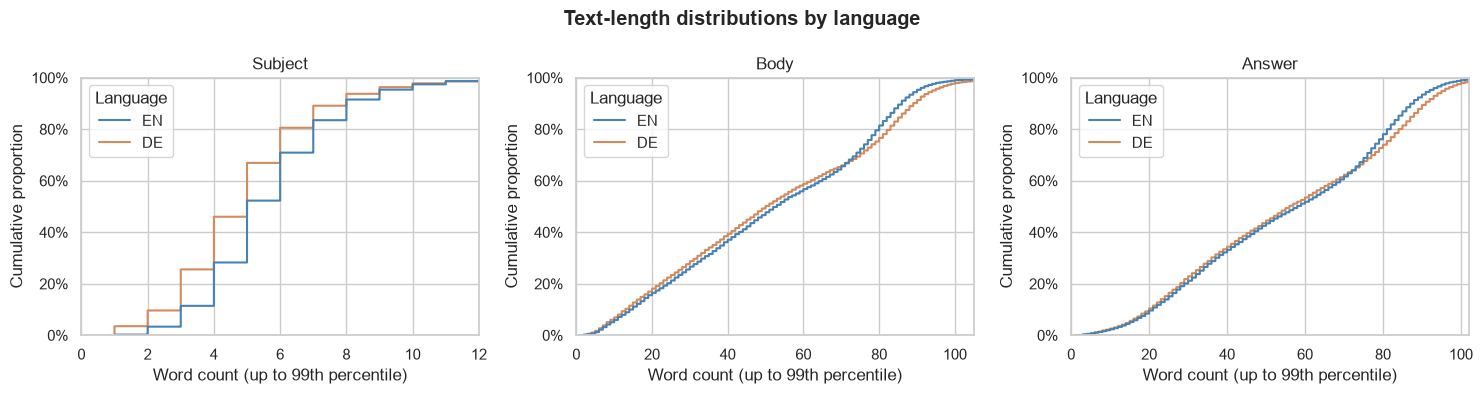

In [11]:
# Store descriptive language summaries separately from effect-size rows.
text_length_records = []
length_effect_records = []

# Derive comparable word and character counts for every modelling field.
for column in text_columns:
    df[f"{column} Word Count"] = df[column].astype("string").str.split().str.len()
    df[f"{column} Character Count"] = df[column].astype("string").str.len()

    # Summarise the complete word-count distribution within each language.
    for language in ["EN", "DE"]:
        values = df.loc[df["Language"] == language, f"{column} Word Count"]
        text_length_records.append(
            {
                "Column": column,
                "Language": language,
                "Count": values.count(),
                "Mean Words": values.mean(),
                "Median Words": values.median(),
                "Q1 Words": values.quantile(0.25),
                "Q3 Words": values.quantile(0.75),
                "P95 Words": values.quantile(0.95),
                "Maximum Words": values.max(),
            }
        )

    # Quantify language-group separation without assuming normality.
    delta = cliffs_delta(
        df.loc[df["Language"] == "EN", f"{column} Word Count"],
        df.loc[df["Language"] == "DE", f"{column} Word Count"],
    )
    length_effect_records.append({"Column": column, "Cliffs Delta": delta})

# Merge descriptive summaries with their field-level Cliff's delta values.
text_length_df = pd.DataFrame(text_length_records).merge(
    pd.DataFrame(length_effect_records), on="Column", how="left"
)
text_length_df.to_csv(
    Config.TEXT_LENGTH_PATH, index=False, encoding="latin-1"
)
display(
    text_length_df.style.format(
        {
            "Mean Words": "{:.1f}", "Median Words": "{:.1f}",
            "Q1 Words": "{:.1f}", "Q3 Words": "{:.1f}",
            "P95 Words": "{:.1f}", "Cliffs Delta": "{:+.3f}",
        }
    )
)

# Draw one empirical cumulative distribution plot per text field.
fig, axes = plt.subplots(1, len(text_columns), figsize=(15, 4))
# Plot both languages on the same axis and limit display to the 99th percentile.
for ax, column in zip(axes, text_columns):
    sns.ecdfplot(
        data=df, x=f"{column} Word Count", hue="Language",
        hue_order=["EN", "DE"], palette=["steelblue", "#D38B5D"], ax=ax,
    )
    upper_limit = df[f"{column} Word Count"].quantile(0.99)
    ax.set_xlim(0, upper_limit)
    ax.set_title(column)
    ax.set_xlabel("Word count (up to 99th percentile)")
    ax.set_ylabel("Cumulative proportion")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

fig.suptitle("Text-length distributions by language", fontweight="bold")
fig.tight_layout()
fig.savefig(
    Config.REP_IMG_DIR / "06_Text_Length_ECDF.png",
    dpi=300, bbox_inches="tight",
)
plt.show()
plt.close(fig)

### Language-label audit

An offline character n-gram classifier provides an independent consistency check between the recorded language label and the ticket text. Probabilities are generated out of fold, so each record is assessed by a model that was not trained on that record. All disagreements are retained as model uncertainty, while only disagreements with at least 90% confidence are flagged as potential label mismatches. These remain audit candidates rather than confirmed errors.

In [12]:
# Combine subject and body to give the detector enough linguistic context.
language_audit_text = (
    df["Subject"].astype("string").fillna("")
    + " "
    + df["Body"].astype("string").fillna("")
)
# Retain the recorded label as the audit target, not assumed ground truth.
language_audit_target = df["Language"].astype("string")
# Learn character patterns that distinguish the two recorded languages.
language_audit_pipeline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=5,
                max_features=20_000,
                sublinear_tf=True,
            ),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=Config.RANDOM_STATE,
            ),
        ),
    ]
)
# Generate every prediction from a fold that excluded that ticket during training.
language_audit_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=Config.RANDOM_STATE,
)
# Request out-of-fold probabilities so low-confidence disagreements are visible.
language_probabilities = cross_val_predict(
    language_audit_pipeline,
    language_audit_text,
    language_audit_target,
    cv=language_audit_cv,
    method="predict_proba",
)
language_classes = np.array(["DE", "EN"])
# Select the most probable label and retain its confidence.
predicted_language = language_classes[language_probabilities.argmax(axis=1)]
prediction_confidence = language_probabilities.max(axis=1)

# Build a record-level audit table that can be inspected outside the notebook.
language_label_audit_df = pd.DataFrame(
    {
        "Index": df["Index"],
        "Recorded Language": language_audit_target,
        "Predicted Language": predicted_language,
        "Prediction Confidence": prediction_confidence,
        "Subject": df["Subject"],
    }
)
# Separate all forced disagreements from high-confidence audit candidates.
language_label_audit_df["Any Disagreement"] = (
    language_label_audit_df["Recorded Language"]
    != language_label_audit_df["Predicted Language"]
)
# Flag only disagreements with at least 90% model confidence.
language_label_audit_df["Potential Mismatch"] = (
    language_label_audit_df["Any Disagreement"]
    & language_label_audit_df["Prediction Confidence"].ge(0.90)
)
language_disagreement_rate = language_label_audit_df["Any Disagreement"].mean()
language_mismatch_rate = language_label_audit_df["Potential Mismatch"].mean()
language_label_audit_df.to_csv(
    Config.LANGUAGE_LABEL_AUDIT_PATH,
    index=False,
    encoding="latin-1",
)

print(
    f"All out-of-fold disagreements: "
    f"{language_label_audit_df['Any Disagreement'].sum():,} "
    f"({language_disagreement_rate:.2%})"
)
print(
    f"High-confidence potential mismatches: "
    f"{language_label_audit_df['Potential Mismatch'].sum():,} "
    f"({language_mismatch_rate:.2%})"
)
display(language_label_audit_df.loc[language_label_audit_df["Potential Mismatch"]].head(20))

All out-of-fold disagreements: 1,564 (6.32%)
High-confidence potential mismatches: 76 (0.31%)


,Index,Recorded Language,Predicted Language,Prediction Confidence,Subject,Any Disagreement,Potential Mismatch
160,160,DE,EN,0.909972,Incident Concerning Device Impact,True,True
227,227,DE,EN,0.904733,Excel's Memory Spike Causing Sluggishness,True,True
256,256,DE,EN,0.915650,Issue with Automated Rebalancing Engines,True,True
450,450,DE,EN,0.926881,Billing Inquiry,True,True
542,542,DE,EN,0.928732,Request for Architectural Specifications of th...,True,True
702,702,DE,EN,0.927397,Multiple Product Failures Alert,True,True
738,738,DE,EN,0.908378,Request for Details on Agile Squad Structure,True,True
755,755,DE,EN,0.977728,Protection of EMR Telemedicine Integrations,True,True
1219,1254,DE,EN,0.949998,Enhancement of Investment Strategies Using Dat...,True,True
1287,1323,DE,EN,0.933089,Health IT Solutions,True,True


### Multivariate language predictability

A regularised logistic regression tests whether language can be predicted from `Priority`, `Type`, `Queue`, `Version`, and tag count jointly. Five-fold stratified cross-validation prevents the diagnostic from relying on a single train/test split. An ROC AUC near 0.50 indicates little joint separation; an AUC at or above the configured threshold triggers caution.

In [13]:
# Select metadata available before text modelling and add ticket tag count.
classifier_data = df[["Priority", "Type", "Queue", "Version", "Language"]].copy()
classifier_data["Tag Count"] = tag_count
# Encode English as the positive class for ROC AUC scoring.
classifier_target = (classifier_data.pop("Language") == "EN").astype(int)

categorical_features = ["Priority", "Type", "Queue", "Version"]
numeric_features = ["Tag Count"]
# One-hot encode categories and standardise the numeric tag-count feature.
preprocessor = ColumnTransformer(
    [
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", StandardScaler(), numeric_features),
    ]
)
# Keep preprocessing inside the pipeline to prevent cross-validation leakage.
classifier = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=Config.RANDOM_STATE)),
    ]
)
# Use reproducible stratified folds that retain the language ratio.
cross_validation = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=Config.RANDOM_STATE
)
# Estimate out-of-sample language predictability for every fold.
auc_scores = cross_val_score(
    classifier,
    classifier_data,
    classifier_target,
    cv=cross_validation,
    scoring="roc_auc",
)

classifier_df = pd.DataFrame(
    {
        "Fold": np.arange(1, len(auc_scores) + 1),
        "ROC AUC": auc_scores,
    }
)
# Add aggregate statistics beneath the individual fold scores.
classifier_summary = pd.DataFrame(
    {
        "Fold": ["Mean", "Std Dev", "Minimum", "Maximum"],
        "ROC AUC": [auc_scores.mean(), auc_scores.std(ddof=1), auc_scores.min(), auc_scores.max()],
    }
)
classifier_output_df = pd.concat([classifier_df, classifier_summary], ignore_index=True)
classifier_output_df.to_csv(
    Config.LANGUAGE_CLASSIFIER_PATH, index=False, encoding="latin-1"
)
display(classifier_output_df.style.format({"ROC AUC": "{:.3f}"}))

,Fold,ROC AUC
0,1,0.520
1,2,0.523
2,3,0.515
3,4,0.506
4,5,0.516
5,Mean,0.516
6,Std Dev,0.006
7,Minimum,0.506
8,Maximum,0.523


### Version sensitivity

Because `Version` showed the largest marginal language difference, `Priority`, `Type`, and `Queue` are rechecked within each version. This identifies whether operational conclusions remain stable after conditioning on the known caution dimension.

In [14]:
# Collect one conditional comparison for each version and metadata dimension.
version_sensitivity_records = []

# Repeat key checks within each application version.
for version in sorted(df["Version"].dropna().unique(), key=str):
    # Isolate one version so its language differences are not confounded by others.
    version_df = df.loc[df["Version"] == version].copy()
    # Skip a version if it lacks either language group.
    if set(version_df["Language"].unique()) != {"EN", "DE"}:
        continue

    # Reassess the main operational dimensions within this version.
    for column in ["Priority", "Type", "Queue"]:
        distribution, table = language_distribution(version_df, column)
        diagnostics = contingency_diagnostics(table)
        l1_distance = distribution["Absolute Pct Diff"].sum()
        version_sensitivity_records.append(
            {
                "Version": version,
                "Dimension": column,
                "English Count": int((version_df["Language"] == "EN").sum()),
                "German Count": int((version_df["Language"] == "DE").sum()),
                "L1 Total Abs Pct Diff": l1_distance,
                "Total Variation Distance": l1_distance / 2,
                "Max Abs Pct Diff": distribution["Absolute Pct Diff"].max(),
                "Cramers V": diagnostics["Cramers V"],
                "P Value": diagnostics["P Value"],
                "Expected Cells Below 5": diagnostics["Expected Cells Below 5"],
            }
        )

# Assemble results and control FDR across all version-specific tests.
version_sensitivity_df = pd.DataFrame(version_sensitivity_records)
version_sensitivity_df["P Value Adj Bh"] = benjamini_hochberg(
    version_sensitivity_df["P Value"]
)
version_sensitivity_df.to_csv(
    Config.VERSION_SENSITIVITY_PATH, index=False, encoding="latin-1"
)
display(
    version_sensitivity_df.style.format(
        {
            "L1 Total Abs Pct Diff": "{:.2%}",
            "Total Variation Distance": "{:.2%}",
            "Max Abs Pct Diff": "{:.2%}",
            "Cramers V": "{:.3f}",
            "P Value": "{:.2e}", "P Value Adj Bh": "{:.2e}",
        }
    )
)

,Version,Dimension,English Count,German Count,L1 Total Abs Pct Diff,Total Variation Distance,Max Abs Pct Diff,Cramers V,P Value,Expected Cells Below 5,P Value Adj Bh
0,400,Priority,8861,7402,2.54%,1.27%,1.27%,0.014,2.20e-01,0,7.53e-01
1,400,Type,8861,7402,2.16%,1.08%,0.98%,0.012,5.02e-01,0,7.53e-01
2,400,Queue,8861,7402,4.38%,2.19%,1.40%,0.026,2.84e-01,0,7.53e-01
3,51,Priority,551,318,5.70%,2.85%,2.85%,0.030,6.70e-01,0,8.46e-01
4,51,Type,551,318,12.78%,6.39%,6.39%,0.068,2.55e-01,0,7.53e-01
5,51,Queue,551,318,11.60%,5.80%,3.08%,0.079,8.00e-01,0,8.46e-01
6,52,Priority,4317,3294,1.32%,0.66%,0.66%,0.007,8.46e-01,0,8.46e-01
7,52,Type,4317,3294,3.49%,1.74%,1.26%,0.020,3.64e-01,0,7.53e-01
8,52,Queue,4317,3294,5.06%,2.53%,1.53%,0.034,4.70e-01,0,7.53e-01


### Decision gate and export

The primary failure gate is practical association strength across marginal and selected joint metadata checks. Caution flags cover total variation, maximum category shifts, adjusted p-values, chi-square assumptions, tag prevalence, text-length effects, multivariate language predictability, and version-conditioned sensitivity.

The English subset is exported only when the primary gate passes. A caution result therefore permits downstream work but requires the flagged dimensions to be considered during interpretation.

In [15]:
# Join inferential statistics with independent-group practical distances.
decision_df = stats_df.merge(
    language_shifts_df,
    on="Dimension",
    how="left",
    validate="one_to_one",
)

# Apply the configured primary effect-size threshold per dimension.
decision_df["Pass Cramers V"] = (
    decision_df["Cramers V"] <= Config.REPRESENTATIVENESS_MAX_CRAMERS_V
)
# Apply practical tolerances to total and category-level shifts.
decision_df["TV Exceeds Threshold"] = (
    decision_df["Total Variation Distance"]
    > Config.REPRESENTATIVENESS_MAX_TOTAL_VARIATION
)
decision_df["Max Category Shift Exceeds Threshold"] = (
    decision_df["Max Abs Pct Diff"]
    > Config.REPRESENTATIVENESS_MAX_CATEGORY_SHIFT
)
# Treat statistical significance and assumption failures as caution flags.
decision_df["Inferential Caution"] = (
    decision_df["P Value Adj Bh"] < Config.REPRESENTATIVENESS_ALPHA_FDR
)
decision_df["Chi Square Assumptions Met"] = (
    decision_df["Expected Cells Below 5"] == 0
)
decision_df["Any Caution"] = (
    decision_df["TV Exceeds Threshold"]
    | decision_df["Max Category Shift Exceeds Threshold"]
    | decision_df["Inferential Caution"]
    | ~decision_df["Chi Square Assumptions Met"]
)
# Assign a readable result to each marginal dimension.
decision_df["Dimension Decision"] = np.select(
    [~decision_df["Pass Cramers V"], decision_df["Any Caution"]],
    ["FAIL", "CAUTION"],
    default="PASS",
)

# Apply the same primary and caution logic to selected interactions.
joint_primary_pass = bool(
    (joint_checks_df["Cramers V"] <= Config.REPRESENTATIVENESS_MAX_CRAMERS_V).all()
)
joint_caution = bool(
    (
        (joint_checks_df["Total Variation Distance"] > Config.REPRESENTATIVENESS_MAX_TOTAL_VARIATION)
        | (joint_checks_df["Max Abs Pct Diff"] > Config.REPRESENTATIVENESS_MAX_CATEGORY_SHIFT)
        | (joint_checks_df["P Value Adj Bh"] < Config.REPRESENTATIVENESS_ALPHA_FDR)
        | (joint_checks_df["Expected Cells Below 5"] > 0)
    ).any()
)
# Convert tag, text, classifier, label-audit, and sensitivity findings to flags.
tag_caution = bool(
    tag_prevalence_df["Absolute Prevalence Diff"].max()
    > Config.REPRESENTATIVENESS_MAX_CATEGORY_SHIFT
)
text_length_caution = bool(
    text_length_df["Cliffs Delta"].abs().max()
    >= Config.REPRESENTATIVENESS_MAX_ABS_CLIFFS_DELTA
)
classifier_mean_auc = float(auc_scores.mean())
classifier_caution = (
    classifier_mean_auc >= Config.REPRESENTATIVENESS_MAX_LANGUAGE_AUC
)
language_label_caution = (
    language_mismatch_rate
    > Config.REPRESENTATIVENESS_MAX_LANGUAGE_LABEL_MISMATCH
)
version_caution = bool(
    (
        (version_sensitivity_df["Total Variation Distance"] > Config.REPRESENTATIVENESS_MAX_TOTAL_VARIATION)
        | (version_sensitivity_df["Max Abs Pct Diff"] > Config.REPRESENTATIVENESS_MAX_CATEGORY_SHIFT)
        | (version_sensitivity_df["Cramers V"] > Config.REPRESENTATIVENESS_MAX_CRAMERS_V)
    ).any()
)

# A primary failure requires a material marginal or joint association.
primary_gate_pass = bool(decision_df["Pass Cramers V"].all()) and joint_primary_pass
# Name each caution source so the final message explains the result.
diagnostic_cautions = {
    "marginal metadata": bool(decision_df["Any Caution"].any()),
    "joint metadata": joint_caution,
    "tag prevalence": tag_caution,
    "text length": text_length_caution,
    "metadata language classifier": classifier_caution,
    "language-label audit": language_label_caution,
    "version sensitivity": version_caution,
}
triggered_cautions = [name for name, triggered in diagnostic_cautions.items() if triggered]

# Resolve the overall result, giving primary failures precedence over cautions.
if not primary_gate_pass:
    overall_decision = "FAIL"
elif triggered_cautions:
    overall_decision = "PASS with caution"
else:
    overall_decision = "PASS"

decision_df["Overall Decision"] = overall_decision
# Export the complete decision table for downstream audit and reporting.
decision_df.to_csv(
    Config.STATISTICAL_SUMMARY_PATH,
    index=False,
    encoding="utf-8",
    float_format="%.6g",
)

print(f"Final decision: {overall_decision}")
print(f"Triggered caution areas: {triggered_cautions or ['None']}")
print(f"Cross-validated language classifier mean ROC AUC: {classifier_mean_auc:.3f}")
display(
    decision_df.style.format(
        {
            "Chi2": "{:.3f}", "P Value": "{:.2e}",
            "P Value Adj Bh": "{:.2e}", "Cramers V": "{:.3f}",
            "Signed Pct Diff at Max": "{:+.2%}",
            "Max Abs Pct Diff": "{:.2%}",
            "L1 Total Abs Pct Diff": "{:.2%}",
            "Total Variation Distance": "{:.2%}",
        }
    )
)

# Publish the English subset only after the primary gate has passed.
if overall_decision != "FAIL":
    df_en.to_csv(Config.ENGLISH_CSV_PATH, index=False, encoding="latin-1")
    df_en.to_parquet(
        Config.ENGLISH_PARQUET_PATH,
        index=False,
        engine="pyarrow",
        compression="snappy",
    )
    print(f"Exported {len(df_en):,} English-language records.")
else:
    print("English-only outputs were not overwritten because the primary gate failed.")

Final decision: PASS with caution
Triggered caution areas: ['marginal metadata', 'joint metadata', 'tag prevalence', 'text length', 'version sensitivity']
Cross-validated language classifier mean ROC AUC: 0.516


,Chi2,P Value,DoF,n,Cramers V,Min Expected Count,Expected Cells Below 5,Dimension,P Value Adj Bh,Max Diff Category,Signed Pct Diff at Max,Max Abs Pct Diff,L1 Total Abs Pct Diff,Total Variation Distance,Pass Cramers V,TV Exceeds Threshold,Max Category Shift Exceeds Threshold,Inferential Caution,Chi Square Assumptions Met,Any Caution,Dimension Decision,Overall Decision
0,2.545,2.80e-01,2,24743,0.010,2276.870630,0,Priority,3.74e-01,Medium,+0.95%,0.95%,1.91%,0.95%,True,False,False,False,True,False,PASS,PASS with caution
1,1.307,7.27e-01,3,24743,0.007,1105.717819,0,Type,7.27e-01,Problem,-0.49%,0.49%,0.98%,0.49%,True,False,False,False,True,False,PASS,PASS with caution
2,14.524,1.05e-01,9,24743,0.024,150.010831,0,Queue,2.10e-01,Product Support,+1.24%,1.24%,3.94%,1.97%,True,False,False,False,True,False,PASS,PASS with caution
3,33.356,5.71e-08,2,24743,0.037,386.823182,0,Version,2.28e-07,400.000000,-2.66%,2.66%,5.33%,2.66%,True,True,True,True,True,True,CAUTION,PASS with caution


Exported 13,729 English-language records.


### Conclusion and handoff

The English subset receives a **PASS with caution**. Marginal Cramér's V values range from 0.007 to 0.037 and the selected joint effects remain below 0.040, comfortably within the configured 0.10 failure threshold. Metadata also has little ability to predict language jointly (mean cross-validated ROC AUC 0.516). The caution areas are distributional rather than evidence that the English subset is unusable:

- `Version` has a total variation distance of 2.66% and drives the strongest adjusted residuals. Its bootstrap interval crosses the configured 2% tolerance, so the size of this shift remains uncertain rather than uniformly excessive.
- `Queue × Priority` and `Queue × Type` have total variation distances of 2.45% and 3.08%, although their Cramér's V values remain small.
- Several common tags differ by more than two percentage points, led by `Bug` (5.00 points), `Feedback` (3.67), and `Security` (2.94).
- Subject word counts show a small language-group effect (Cliff's delta 0.223); body and answer length effects are negligible.
- Version-conditioned checks identify larger uncertainty in version 51 because it contains fewer records.

These findings support downstream English-only modelling, but results should be checked by `Version`, important tag groups, and operational segments. The English modelling fields contain no null, blank, residual-formatting, or replacement-character blockers. Short subjects are common and should not be treated as errors automatically. The offline language audit identifies 76 high-confidence candidates (0.31%), below the configured 1% caution threshold; these and the isolated duplicate bodies should be reviewed rather than removed automatically.

The conclusion applies to measured metadata, tags, and text-readiness properties. It does not establish semantic equivalence between English and German tickets.